# 07 - Ingeniería de variables

**Objetivo.** Construir las variables necesarias para responder las preguntas y contrastar las hipótesis, a partir de la base consolidada (notebook 04) y de las fuentes externas integradas en el notebook 06.

| Bloque | Variables | Responde a |
|---|---|---|
| Alcance | `en_alcance`, flags de ubicación y de operaciones múltiples | delimitación de la unidad de análisis |
| Moneda | `tc_mep`, `precio_venta_usd`, `precio_mensual_usd` | todos los KPIs de precio |
| Precios comparables | `precio_m2_usd`, `precio_por_ambiente_usd` | KPIs de precio por m² y por ambiente; H3 |
| Entorno por publicación | distancias a transporte, hospital y espacio verde; conteos a 500 m | H1, H2b, H3 |
| Contexto territorial | variables por barrio (densidades) y por comuna (Censo) | H1, H2a, H2b, H4 |
| KPIs agregados | tablas por barrio (48) y por comuna (15) | preguntas descriptivas y diagnósticas |

Para cada variable se documenta fórmula, unidad, fuente de sus componentes, tratamiento de faltantes y validación de rangos (sección 9). No se construyen índices compuestos.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'data' / 'raw').exists() and (path / 'README.md').exists():
            return path
    raise FileNotFoundError('No se encontró la raíz del repo. Ejecutar dentro del proyecto.')


sys.path.insert(0, str(find_repo_root()))
from src import config, externas, geo
from src import features as F

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.edgecolor': '#52514e', 'axes.labelcolor': '#52514e', 'xtick.color': '#52514e',
                     'ytick.color': '#52514e', 'font.size': 9})
COLORES_OPERACION = {'venta': '#2a78d6', 'alquiler': '#eb6834', 'alquiler_temporal': '#1baf7a'}
CLAVE = ['id_publicacion', 'tipo_operacion_norm']
N_MINIMO = 30  # publicaciones mínimas por celda (barrio x operación) para reportar medianas

## 1. Carga de insumos

In [2]:
base = pd.read_csv(config.BASE_CONSOLIDADA, low_memory=False, dtype={'id_publicacion': str})
ubicacion = pd.read_csv(config.PROCESSED_DIR / 'publicaciones_ubicacion_v1.csv', dtype={'id_publicacion': str})
contexto_barrio = pd.read_csv(config.PROCESSED_DIR / 'features_contextuales_barrio_v1.csv')
censo = pd.read_csv(config.PROCESSED_DIR / 'censo_2022_comunas_v1.csv')
barrios = geo.cargar_barrios(config.EXTERNAS_RAW_DIR / 'barrios.geojson')
fuentes = externas.cargar_todas_las_fuentes_puntuales()

df = base.merge(ubicacion.drop(columns=['fuente_norm']), on=CLAVE, how='left', validate='one_to_one')
assert len(df) == len(base)
print('Base:', base.shape, '| con ubicación:', df.shape)
print('Barrios:', len(contexto_barrio), '| comunas:', len(censo))

Base: (67887, 100) | con ubicación: (67887, 109)
Barrios: 48 | comunas: 15


## 2. Alcance

No se eliminan filas: se marca qué publicaciones entran en los KPIs.

- **Fuera de CABA:** avisos cuyo barrio declarado es una localidad de otra jurisdicción y que no tienen coordenadas dentro de la Ciudad.
- **Sin barrio oficial:** no pueden asignarse a ningún territorio (denominaciones ambiguas o texto no reconocible). Entran en los análisis por publicación, no en los KPIs territoriales.
- **Ids en más de una operación:** la base ya no tiene duplicados dentro de una misma operación, pero hay avisos que aparecen a la vez en dos búsquedas (por ejemplo, alquiler y alquiler temporario). Se conservan en ambas, porque cada búsqueda representa oferta publicada para esa modalidad, y se marcan para poder hacer análisis de sensibilidad.

In [3]:
df['id_en_multiples_operaciones_flag'] = df.groupby('id_publicacion')['tipo_operacion_norm'].transform('nunique') > 1
df['en_alcance'] = ~df['fuera_de_caba_flag'].fillna(False).astype(bool)
df['en_alcance_territorial'] = df['en_alcance'] & df['barrio_oficial'].notna()

alcance = df.groupby('fuente_norm').agg(
    publicaciones=('en_alcance', 'size'),
    fuera_de_caba=('fuera_de_caba_flag', 'sum'),
    sin_barrio_oficial=('barrio_oficial', lambda s: s.isna().sum()),
    en_alcance_territorial=('en_alcance_territorial', 'sum'),
    id_en_multiples_operaciones=('id_en_multiples_operaciones_flag', 'sum'))
display(alcance)

pares = (df[df['id_en_multiples_operaciones_flag']].groupby('id_publicacion')['tipo_operacion_norm']
         .agg(lambda s: ' + '.join(sorted(s))).value_counts().rename('avisos').to_frame())
display(pares)

,publicaciones,fuera_de_caba,sin_barrio_oficial,en_alcance_territorial,id_en_multiples_operaciones
fuente_norm,,,,,
airbnb,9596,0,76,9520,0
argenprop,162,0,8,154,0
mercado_libre,57149,13,102,57047,2459
zonaprop,980,0,9,971,0


,avisos
tipo_operacion_norm,
alquiler + alquiler_temporal,1115
alquiler_temporal + venta,109
alquiler + alquiler_temporal + venta,3
alquiler + venta,1


**Lectura.** Los avisos en dos operaciones son casi todos combinaciones de alquiler permanente y temporario de Mercado Libre: el mismo departamento ofrecido en ambas modalidades. Es un dato en sí mismo para H4 (oferta que se mueve entre modalidades), además de un aspecto a controlar.

## 3. Normalización monetaria

| Aspecto | Criterio |
|---|---|
| Fuente | API pública de ArgentinaDatos, serie diaria del dólar MEP (casa "bolsa"), snapshot en `data/raw/externas/dolar_mep_diario.json` |
| Cotización | Vendedor |
| Fecha de referencia | Fecha de extracción de cada aviso (`scraped_at_utc` en hora de Argentina; para Airbnb, `fecha_extraccion`) |
| Días no hábiles | Última cotización disponible anterior |
| Fórmula | `precio_usd = precio_ars / tc_mep`; los precios publicados en USD no se modifican |
| Por qué MEP | Es el tipo de cambio de referencia del mercado inmobiliario, que cotiza en dólares billete |

,fecha_precio,fecha_tc,tc_mep,avisos
0,2026-08-15,2026-08-15,1521.6,40872
1,2026-08-16,2026-08-16,1521.6,2
2,2026-08-17,2026-08-17,1521.6,485
3,2026-09-03,2026-09-03,1535.2,6593
4,2026-09-05,2026-09-05,1525.3,17214
5,2026-09-06,2026-09-06,1525.3,2721


Variación máxima del MEP entre fechas de extracción: 0.89 %


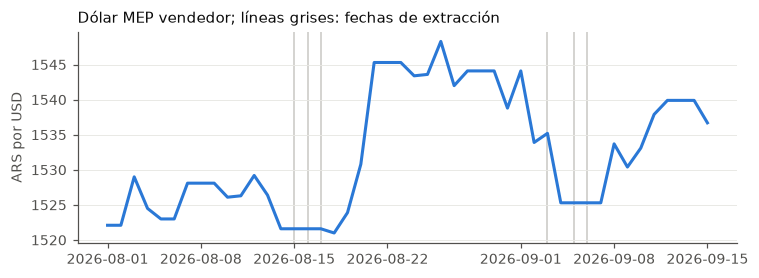

In [4]:
mep = F.cargar_dolar_mep()
df['fecha_precio'] = F.fecha_referencia_precio(df)
df['tc_mep'], df['fecha_tc'] = F.asignar_tipo_cambio(df['fecha_precio'], mep)

uso_tc = (df.groupby(['fecha_precio', 'fecha_tc', 'tc_mep']).size().rename('avisos').reset_index())
display(uso_tc)
print(f"Variación máxima del MEP entre fechas de extracción: "
      f"{(uso_tc['tc_mep'].max() / uso_tc['tc_mep'].min() - 1) * 100:.2f} %")
assert df['tc_mep'].notna().all(), 'Hay avisos sin tipo de cambio'

ventana = mep[(mep['fecha'] >= '2026-08-01') & (mep['fecha'] <= '2026-09-15')]
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.plot(ventana['fecha'], ventana['venta'], color='#2a78d6', lw=2)
for f in uso_tc['fecha_tc'].unique():
    ax.axvline(f, color='#c9c8c3', lw=1, zorder=0)
ax.set_ylabel('ARS por USD')
ax.set_title('Dólar MEP vendedor; líneas grises: fechas de extracción', loc='left', fontsize=10, color='#0b0b0b')
ax.grid(axis='y', color='#e8e7e3', lw=0.6)
plt.tight_layout()
plt.show()

**Lectura.** El MEP se mantuvo estable durante la extracción (variación menor al 1% entre las fechas usadas), así que la elección de la fecha de referencia casi no afecta los resultados. La diferencia entre MEP y oficial en el período fue de 1-2%, por lo que usar el oficial tampoco cambiaría las conclusiones; se elige el MEP por ser la referencia del mercado.

## 4. Precios comparables

| Variable | Fórmula | Unidad | Aplica a |
|---|---|---|---|
| `precio_venta_usd` | precio publicado en USD | USD | venta |
| `precio_mensual_usd` | precio mensual publicado en USD; Airbnb: cotización de 30 noches | USD/mes | alquiler y temporario |
| `precio_m2_usd` | precio / `superficie_ref_m2` | USD/m² (venta) y USD/m²/mes (alquiler) | venta y alquiler permanente |
| `precio_por_ambiente_usd` | precio / `ambientes_ref` (monoambiente = 1) | USD o USD/mes por ambiente | todas |

`precio_por_ambiente_usd` reemplaza al "precio por dormitorio" de la PreEntrega 1: Mercado Libre informa dormitorios en menos del 1% de los avisos, mientras que ambientes está en más del 95%. En Airbnb los ambientes se derivan como dormitorios + 1, la misma convención de los portales.

**Alquiler temporario: dos fuentes que no se mezclan.** El precio de Mercado Libre temporario es el precio mensual publicado. El de Airbnb es la cotización para 30 noches desde el 20/10/2026, para dos huéspedes, sin tarifas de limpieza ni de servicio (15-25% adicional) y solo de anuncios que aceptan estadías de un mes. Se reportan siempre por separado.

In [5]:
precios = F.construir_precios(df, df['tc_mep'].to_numpy())
df = pd.concat([df, precios], axis=1)
df = pd.concat([df, F.flags_rango(df)], axis=1)

resumen_precios = (df[df['en_alcance']]
                   .groupby(['tipo_operacion_norm', 'fuente_norm'])[['precio_venta_usd', 'precio_mensual_usd',
                                                                      'precio_m2_usd', 'precio_por_ambiente_usd']]
                   .median().round(1))
display(resumen_precios)
display(df.filter(like='_fuera_rango_flag').mean().mul(100).round(2).rename('% fuera de rango').to_frame())

precio_venta_usd  precio_mensual_usd  precio_m2_usd  precio_por_ambiente_usd
tipo_operacion_norm fuente_norm                                                                                
alquiler            argenprop                   NaN               618.8           13.5                    293.1
                    mercado_libre               NaN               570.4           13.8                    349.7
                    zonaprop                    NaN               950.0           16.2                    500.0
alquiler_temporal   airbnb                      NaN              1826.0            NaN                    979.0
                    mercado_libre               NaN               750.0            NaN                    450.0
venta               argenprop              148500.0                 NaN         2852.4                  64000.0
                    mercado_libre          137500.0                 NaN         2717.4                  68750.0
                    zonaprop               187000.0                 NaN         2614.9                  82050.0

,% fuera de rango
precio_m2_usd_fuera_rango_flag,0.26
precio_mensual_usd_fuera_rango_flag,0.80
precio_venta_usd_fuera_rango_flag,0.02


In [6]:
def describir(serie):
    s = serie.dropna()
    return pd.Series({'n': len(s), 'media': s.mean(), 'mediana': s.median(), 'desvio': s.std(),
                      'p10': s.quantile(.1), 'p25': s.quantile(.25), 'p75': s.quantile(.75), 'p90': s.quantile(.9),
                      'asimetria': s.skew(), 'cv': s.std() / s.mean()})


estadisticos = pd.DataFrame({
    'venta: USD/m2': describir(df.loc[df['tipo_operacion_norm'].eq('venta'), 'precio_m2_usd']),
    'alquiler: USD/m2/mes': describir(df.loc[df['tipo_operacion_norm'].eq('alquiler'), 'precio_m2_usd']),
    'alquiler: USD/mes': describir(df.loc[df['tipo_operacion_norm'].eq('alquiler'), 'precio_mensual_usd']),
    'temporario MeLi: USD/mes': describir(df.loc[df['tipo_operacion_norm'].eq('alquiler_temporal')
                                                 & df['fuente_norm'].eq('mercado_libre'), 'precio_mensual_usd']),
    'Airbnb 30 noches: USD': describir(df.loc[df['fuente_norm'].eq('airbnb'), 'precio_mensual_usd']),
}).T.round(2)
display(estadisticos)

,n,media,mediana,desvio,p10,p25,p75,p90,asimetria,cv
venta: USD/m2,43290.0,3059.78,2717.39,4663.74,1583.33,2069.44,3505.12,4583.33,86.29,1.52
alquiler: USD/m2/mes,10397.0,31.06,13.91,846.19,9.83,11.49,17.73,24.49,96.12,27.24
alquiler: USD/mes,10452.0,1304.22,586.24,7983.42,380.25,445.81,983.41,1950.00,33.64,6.12
temporario MeLi: USD/mes,4494.0,4725.29,750.00,24164.69,367.14,520.28,1200.00,2000.00,8.76,5.11
Airbnb 30 noches: USD,9596.0,5309.42,1826.00,55713.95,1114.00,1372.00,2717.00,4370.50,27.21,10.49


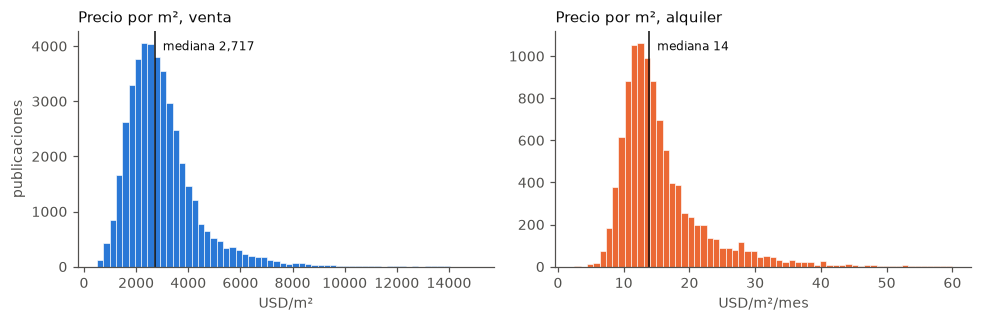

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, op, unidad in [(axes[0], 'venta', 'USD/m²'), (axes[1], 'alquiler', 'USD/m²/mes')]:
    v = df.loc[df['tipo_operacion_norm'].eq(op) & ~df['precio_m2_usd_fuera_rango_flag'], 'precio_m2_usd'].dropna()
    ax.hist(v, bins=60, color=COLORES_OPERACION[op], edgecolor='white', linewidth=0.4)
    ax.axvline(v.median(), color='#0b0b0b', lw=1)
    ax.text(v.median(), ax.get_ylim()[1] * 0.92, f'  mediana {v.median():,.0f}', fontsize=8, color='#0b0b0b')
    ax.set_xlabel(unidad)
    ax.set_title(f'Precio por m², {op}', loc='left', fontsize=10, color='#0b0b0b')
axes[0].set_ylabel('publicaciones')
plt.tight_layout()
plt.show()

**Lectura.** Las dos distribuciones de precio por m² son asimétricas a la derecha (cola de unidades de alta gama), por lo que la mediana es el estadístico de posición adecuado para los KPIs y la media se reporta solo como referencia. La relación entre las medianas implica que el alquiler anual equivale a alrededor del 6% del valor de venta por m², un orden de magnitud consistente con el mercado porteño, lo que funciona como control de que la conversión monetaria y las superficies son coherentes entre operaciones. Los valores fuera del rango plausible (menos del 1%) se marcan y se excluyen de los KPIs, sin borrarlos.

## 5. Entorno urbano por publicación

Para cada publicación con coordenadas dentro de CABA:

| Variable | Fórmula | Unidad |
|---|---|---|
| `dist_subte_m`, `dist_tren_m`, `dist_metrobus_m`, `dist_hospitales_m` | distancia haversine al punto más cercano | metros |
| `dist_transporte_masivo_m` | mínimo de las tres distancias de transporte | metros |
| `dist_espacio_verde_m` | distancia al vértice más cercano de una plaza, parque o jardín (aproxima la distancia al borde) | metros |
| `n_culturales_500m`, `n_gastronomia_500m`, `n_educacion_500m` | puntos a menos de 500 m | cantidad |

`dist_transporte_masivo_m` no es un índice: es la distancia al medio masivo más cercano, sin ponderaciones. H3 la usa junto con las distancias por medio.

In [8]:
fuentes_entorno = dict(fuentes)
verdes = fuentes['espacios_verdes']
entorno = F.variables_entorno(df['lat'], df['lon'], fuentes_entorno, externas.vertices_espacios_verdes(verdes))
entorno.index = df.index
df = pd.concat([df, entorno], axis=1)

cols_entorno = list(entorno.columns)
cobertura_entorno = (df.groupby('fuente_norm')['dist_subte_m'].apply(lambda s: s.notna().mean() * 100)
                     .round(1).rename('% con variables de entorno').to_frame())
display(cobertura_entorno)
display(df[cols_entorno].describe(percentiles=[.1, .5, .9]).T.round(0))

,% con variables de entorno
fuente_norm,
airbnb,99.2
argenprop,95.1
mercado_libre,86.2
zonaprop,0.0


,count,mean,std,min,10%,50%,90%,max
dist_subte_m,58964.0,976.0,1087.0,0.0,188.0,569.0,2585.0,5805.0
dist_tren_m,58964.0,1040.0,551.0,13.0,374.0,953.0,1816.0,2971.0
dist_metrobus_m,58964.0,1028.0,745.0,0.0,180.0,832.0,2187.0,3122.0
dist_hospitales_m,58964.0,1296.0,679.0,10.0,460.0,1217.0,2282.0,3664.0
dist_espacio_verde_m,58964.0,320.0,201.0,0.0,91.0,284.0,607.0,1199.0
dist_transporte_masivo_m,58964.0,429.0,302.0,0.0,127.0,364.0,783.0,2904.0
n_culturales_500m,58964.0,28.0,34.0,0.0,3.0,14.0,74.0,199.0
n_gastronomia_500m,58964.0,27.0,34.0,0.0,2.0,13.0,70.0,250.0
n_educacion_500m,58964.0,9.0,4.0,0.0,4.0,9.0,15.0,25.0


In [9]:
validacion_entorno = pd.DataFrame({
    'minimo': df[cols_entorno].min(), 'maximo': df[cols_entorno].max(),
    'negativos': (df[cols_entorno] < 0).sum(),
})
display(validacion_entorno.round(0))
assert (df[cols_entorno].fillna(0) >= 0).all().all()
assert df['dist_transporte_masivo_m'].max() < 5_000, 'Distancia al transporte implausible para CABA'

,minimo,maximo,negativos
dist_subte_m,0.0,5805.0,0
dist_tren_m,13.0,2971.0,0
dist_metrobus_m,0.0,3122.0,0
dist_hospitales_m,10.0,3664.0,0
dist_espacio_verde_m,0.0,1199.0,0
dist_transporte_masivo_m,0.0,2904.0,0
n_culturales_500m,0.0,199.0,0
n_gastronomia_500m,0.0,250.0,0
n_educacion_500m,0.0,25.0,0


**Lectura.** La mitad de las publicaciones está a pocas cuadras del medio de transporte masivo más cercano y el máximo no supera unos pocos kilómetros, coherente con la cobertura de la red en CABA. Los conteos a 500 m tienen distribuciones muy asimétricas: la oferta cultural y gastronómica se concentra en pocos barrios centrales. ZonaProp no tiene estas variables (no publica dirección) y Airbnb las tiene con el ruido de sus coordenadas ofuscadas.

## 6. Contexto territorial

Se agregan a cada publicación las densidades de su barrio (notebook 06) y las variables censales de su comuna. Son variables de contexto: todas las publicaciones de un mismo barrio o comuna comparten el mismo valor.

In [10]:
ctx_cols = [c for c in contexto_barrio.columns if c not in ('comuna',)]
df = df.merge(contexto_barrio[ctx_cols].rename(columns={'area_km2': 'area_km2_barrio'}),
              on='barrio_oficial', how='left', validate='many_to_one')
censo_cols = ['comuna', 'poblacion_total', 'viviendas_particulares', 'hogares', 'tamano_medio_hogar',
              'pct_hogares_inquilinos', 'pct_viviendas_departamento', 'pct_viviendas_uso_temporal',
              'pct_viviendas_en_alquiler_o_venta']
df = df.merge(censo[censo_cols].add_suffix('_comuna').rename(columns={'comuna_comuna': 'comuna_oficial'}),
              on='comuna_oficial', how='left', validate='many_to_one')
print('Con contexto de barrio:', round(df['area_km2_barrio'].notna().mean() * 100, 1), '%')
print('Con contexto censal:', round(df['poblacion_total_comuna'].notna().mean() * 100, 1), '%')

Con contexto de barrio: 99.7 %
Con contexto censal: 99.7 %


## 7. KPIs por barrio

Se calculan sobre publicaciones en alcance territorial y con precios dentro de rango. Las medianas se reportan solo si la celda barrio x operación tiene al menos 30 publicaciones; si no, quedan como faltantes para no comparar barrios con muestras muy chicas.

**Sobre la participación de cada operación.** La proporción "venta vs alquiler" dentro de un barrio depende de cuántas páginas se extrajeron por búsqueda, no solo del mercado (hay 4 avisos de venta por cada alquiler en la base). Por eso el indicador principal es la **participación del barrio dentro de cada operación** (qué parte de todos los alquileres está en el barrio), que sí es comparable entre barrios. La participación de la operación dentro del barrio se incluye solo como referencia.

In [11]:
kpi = df[df['en_alcance_territorial']].copy()
for col in ['precio_m2_usd', 'precio_mensual_usd', 'precio_venta_usd']:
    kpi.loc[kpi[f'{col}_fuera_rango_flag'], col] = np.nan


def mediana_min(s):
    s = s.dropna()
    return s.median() if len(s) >= N_MINIMO else np.nan


conteos = kpi.pivot_table(index='barrio_oficial', columns='tipo_operacion_norm', values='id_publicacion',
                          aggfunc='size', fill_value=0).add_prefix('n_')
conteos['n_airbnb'] = kpi[kpi['fuente_norm'].eq('airbnb')].groupby('barrio_oficial').size()
conteos = conteos.fillna(0).astype(int)

kpis_barrio = barrios[['barrio_oficial', 'comuna', 'area_km2']].set_index('barrio_oficial').join(conteos).fillna(0)
for op in ['venta', 'alquiler', 'alquiler_temporal']:
    kpis_barrio[f'pct_del_total_{op}'] = 100 * kpis_barrio[f'n_{op}'] / kpis_barrio[f'n_{op}'].sum()
total_barrio = kpis_barrio[['n_venta', 'n_alquiler', 'n_alquiler_temporal']].sum(axis=1)
for op in ['venta', 'alquiler', 'alquiler_temporal']:
    kpis_barrio[f'participacion_{op}_en_barrio_ref'] = 100 * kpis_barrio[f'n_{op}'] / total_barrio
kpis_barrio['airbnb_por_km2'] = kpis_barrio['n_airbnb'] / kpis_barrio['area_km2']

g = kpi.groupby(['barrio_oficial', 'tipo_operacion_norm'])
kpis_barrio['mediana_precio_m2_venta_usd'] = g['precio_m2_usd'].agg(mediana_min).xs('venta', level=1)
kpis_barrio['mediana_precio_m2_alquiler_usd'] = g['precio_m2_usd'].agg(mediana_min).xs('alquiler', level=1)
kpis_barrio['mediana_alquiler_mensual_usd'] = g['precio_mensual_usd'].agg(mediana_min).xs('alquiler', level=1)

por_amb = kpi.groupby(['barrio_oficial', 'fuente_norm', 'tipo_operacion_norm'])['precio_por_ambiente_usd'].agg(mediana_min)
perm = kpi[kpi['tipo_operacion_norm'].eq('alquiler')].groupby('barrio_oficial')['precio_por_ambiente_usd'].agg(mediana_min)
airbnb = por_amb.xs(('airbnb', 'alquiler_temporal'), level=(1, 2))
meli_temp = por_amb.xs(('mercado_libre', 'alquiler_temporal'), level=(1, 2))
kpis_barrio['brecha_airbnb_vs_permanente_pct'] = 100 * (airbnb / perm - 1)
kpis_barrio['brecha_meli_temporario_vs_permanente_pct'] = 100 * (meli_temp / perm - 1)

kpis_barrio = kpis_barrio.join(contexto_barrio.set_index('barrio_oficial').filter(regex='^densidad_|^pct_superficie'))
kpis_barrio = kpis_barrio.reset_index()
display(kpis_barrio.sort_values('n_alquiler', ascending=False).head(12).round(1))

,barrio_oficial,comuna,area_km2,n_alquiler,n_alquiler_temporal,n_venta,n_airbnb,pct_del_total_venta,pct_del_total_alquiler,pct_del_total_alquiler_temporal,participacion_venta_en_barrio_ref,participacion_alquiler_en_barrio_ref,participacion_alquiler_temporal_en_barrio_ref,airbnb_por_km2,mediana_precio_m2_venta_usd,mediana_precio_m2_alquiler_usd,mediana_alquiler_mensual_usd,brecha_airbnb_vs_permanente_pct,brecha_meli_temporario_vs_permanente_pct,densidad_subte_km2,densidad_tren_km2,densidad_metrobus_km2,densidad_hospitales_km2,densidad_educacion_km2,densidad_culturales_km2,densidad_gastronomia_km2,densidad_espacios_verdes_km2,pct_superficie_verde
20,Palermo,14,15.9,1431,4216,2592,3222,6.0,13.7,30.1,31.5,17.4,51.2,202.4,3653.8,15.9,750.0,154.7,33.6,0.4,0.2,0.9,0.1,6.6,18.3,29.3,3.4,12.4
27,Recoleta,2,6.4,1007,1770,2001,1322,4.6,9.7,12.7,41.9,21.1,37.0,205.5,3082.9,14.7,700.0,143.9,27.1,1.1,0.2,0.0,0.5,10.1,50.1,50.8,4.8,4.7
4,Belgrano,13,8.1,743,703,2108,491,4.9,7.1,5.0,59.3,20.9,19.8,60.9,3684.2,15.4,700.0,146.2,18.6,0.2,0.6,3.1,0.1,9.2,12.8,8.8,4.7,12.9
7,Caballito,6,6.9,689,265,1938,140,4.5,6.6,1.9,67.0,23.8,9.2,20.4,2796.9,12.7,524.5,160.5,43.6,0.6,0.1,0.1,0.6,12.0,14.9,18.2,1.5,2.4
26,Puerto Madero,1,5.0,608,373,1282,186,3.0,5.8,2.7,56.7,26.9,16.5,36.9,6387.4,27.4,2400.0,69.6,0.0,0.0,0.0,0.0,0.0,0.4,3.8,9.5,2.8,52.4
1,Almagro,5,4.1,450,617,2197,371,5.1,4.3,4.4,67.3,13.8,18.9,91.6,2500.0,12.6,458.9,160.0,21.4,1.2,0.0,0.0,0.2,14.1,36.5,15.6,0.2,0.2
47,Villa Urquiza,12,5.4,428,166,2000,100,4.6,4.1,1.2,77.1,16.5,6.4,18.4,3094.0,13.8,524.5,163.8,29.8,0.4,0.4,0.0,0.0,9.2,5.7,5.1,1.3,0.3
19,Nuñez,13,4.5,404,374,1788,218,4.1,3.9,2.7,69.7,15.7,14.6,48.5,3893.3,16.3,721.2,117.5,13.9,0.0,0.4,6.9,0.0,7.6,7.3,6.2,1.3,8.9
12,Flores,7,8.6,347,86,1931,44,4.5,3.3,0.6,81.7,14.7,3.6,5.1,2138.9,11.5,458.9,194.7,19.2,0.6,0.1,0.6,0.2,9.8,6.2,9.9,2.3,1.5
28,Retiro,1,4.5,343,627,982,471,2.3,3.3,4.5,50.3,17.6,32.1,104.3,2607.0,14.3,850.0,110.2,17.6,0.9,0.7,5.1,0.0,5.1,34.6,24.1,7.5,2.1


**Brecha temporal vs permanente** = (mediana del precio mensual por ambiente del temporario / mediana del precio mensual por ambiente del alquiler permanente) - 1. Ambos precios están en USD por mes y por ambiente. Diferencias que la brecha no corrige: el temporario suele incluir muebles, servicios y expensas; el permanente no incluye expensas; Airbnb además excluye sus tarifas.

## 8. KPIs por comuna

Agregan las publicaciones a las 15 comunas y las relacionan con el stock del Censo. Son los únicos indicadores normalizados por población, viviendas u hogares, porque el Censo no baja a barrio.

In [12]:
cnt_c = kpi.pivot_table(index='comuna_oficial', columns='tipo_operacion_norm', values='id_publicacion',
                        aggfunc='size', fill_value=0).add_prefix('n_')
cnt_c['n_airbnb'] = kpi[kpi['fuente_norm'].eq('airbnb')].groupby('comuna_oficial').size()
kpis_comuna = censo.set_index('comuna').join(cnt_c.fillna(0).astype(int))

kpis_comuna['venta_por_1000_viviendas'] = 1000 * kpis_comuna['n_venta'] / kpis_comuna['viviendas_particulares']
kpis_comuna['alquiler_por_1000_viviendas'] = 1000 * kpis_comuna['n_alquiler'] / kpis_comuna['viviendas_particulares']
kpis_comuna['airbnb_por_1000_viviendas'] = 1000 * kpis_comuna['n_airbnb'] / kpis_comuna['viviendas_particulares']
kpis_comuna['alquiler_por_1000_hogares_inquilinos'] = 1000 * kpis_comuna['n_alquiler'] / kpis_comuna['hogares_inquilinos']
kpis_comuna['publicaciones_por_1000_hab'] = (1000 * kpis_comuna[['n_venta', 'n_alquiler', 'n_alquiler_temporal']].sum(axis=1)
                                             / kpis_comuna['poblacion_total'])
kpis_comuna['airbnb_por_cada_alquiler_permanente'] = kpis_comuna['n_airbnb'] / kpis_comuna['n_alquiler']
kpis_comuna = kpis_comuna.reset_index()
kpis_comuna['comuna'] = kpis_comuna['comuna'].astype(int)

vista = ['comuna', 'n_alquiler', 'n_airbnb', 'alquiler_por_1000_viviendas', 'airbnb_por_1000_viviendas',
         'alquiler_por_1000_hogares_inquilinos', 'airbnb_por_cada_alquiler_permanente',
         'pct_viviendas_uso_temporal', 'tamano_medio_hogar']
display(kpis_comuna[vista].sort_values('airbnb_por_1000_viviendas', ascending=False).round(2))

,comuna,n_alquiler,n_airbnb,alquiler_por_1000_viviendas,airbnb_por_1000_viviendas,alquiler_por_1000_hogares_inquilinos,airbnb_por_cada_alquiler_permanente,pct_viviendas_uso_temporal,tamano_medio_hogar
13,14,1431,3222,9.49,21.37,27.72,2.25,1.17,1.94
0,1,1819,1989,13.98,15.28,35.34,1.09,1.29,2.07
1,2,1007,1322,9.37,12.30,29.08,1.31,2.96,1.92
12,13,1390,951,9.55,6.54,31.11,0.68,0.52,2.06
14,15,628,511,6.11,4.97,18.94,0.81,0.31,2.15
4,5,519,399,4.90,3.76,13.50,0.77,0.37,2.06
2,3,478,405,4.34,3.67,10.77,0.85,0.67,2.09
11,12,722,206,5.97,1.70,19.68,0.29,0.22,2.18
3,4,237,137,2.35,1.36,7.54,0.58,0.21,2.49
5,6,689,140,6.46,1.31,20.46,0.20,0.36,2.11


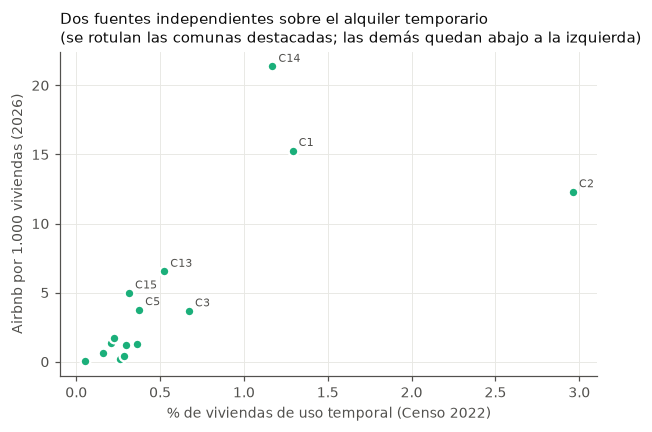

Correlación de Spearman (n = 15 comunas): 0.83


In [13]:
fig, ax = plt.subplots(figsize=(5.6, 4))
ax.scatter(kpis_comuna['pct_viviendas_uso_temporal'], kpis_comuna['airbnb_por_1000_viviendas'],
           s=40, color='#1baf7a', edgecolor='white', linewidth=1.5, zorder=3)
destacadas = kpis_comuna[(kpis_comuna['airbnb_por_1000_viviendas'] > 3) | (kpis_comuna['pct_viviendas_uso_temporal'] > 0.5)]
for _, r in destacadas.iterrows():
    ax.annotate(f"C{int(r['comuna'])}", (r['pct_viviendas_uso_temporal'], r['airbnb_por_1000_viviendas']),
                xytext=(4, 3), textcoords='offset points', fontsize=7.5, color='#52514e')
ax.set_xlabel('% de viviendas de uso temporal (Censo 2022)')
ax.set_ylabel('Airbnb por 1.000 viviendas (2026)')
ax.set_title('Dos fuentes independientes sobre el alquiler temporario\n(se rotulan las comunas destacadas; las demás quedan abajo a la izquierda)', loc='left', fontsize=10, color='#0b0b0b')
ax.grid(color='#e8e7e3', lw=0.6)
plt.tight_layout()
plt.show()
rho = kpis_comuna[['pct_viviendas_uso_temporal', 'airbnb_por_1000_viviendas']].corr(method='spearman').iloc[0, 1]
print(f'Correlación de Spearman (n = 15 comunas): {rho:.2f}')

**Lectura.** La densidad de Airbnb medida con los avisos de 2026 y la proporción de viviendas de uso temporal medida por el Censo 2022 ordenan las comunas de forma muy parecida. Es una validación cruzada: la concentración del alquiler temporario en las comunas 1, 2 y 14 no es un artefacto del scraping de Airbnb. Con 15 comunas y datos agregados esto es descriptivo; no permite inferir relaciones a nivel vivienda.

## 9. Diccionario de variables derivadas

In [14]:
D = [
    ('barrio_oficial', 'Polígono oficial si hay coordenadas; si no, barrio declarado mapeado', 'categoría', 'GeoJSON GCBA; USIG; portales', 'Sin asignar si el texto es ambiguo o no reconocible', 'Pertenece a los 48 barrios oficiales'),
    ('comuna_oficial', 'Comuna del barrio oficial', 'número 1-15', 'GeoJSON GCBA', 'Hereda los faltantes de barrio_oficial', 'Rango 1-15'),
    ('lat, lon', 'Airbnb: propias; resto: geocodificación USIG', 'grados WGS84', 'Airbnb; USIG', 'NaN si no se geocodificó o cae fuera de CABA', 'Punto dentro de un barrio oficial'),
    ('en_alcance', 'No es una localidad fuera de CABA', 'booleano', 'barrio declarado + coordenadas', 'No aplica', '-'),
    ('id_en_multiples_operaciones_flag', 'El id aparece en más de una operación', 'booleano', 'base consolidada', 'No aplica', '-'),
    ('tc_mep', 'MEP vendedor de la fecha de extracción (última cotización previa si no es hábil)', 'ARS/USD', 'ArgentinaDatos', 'Sin faltantes', 'Entre 1.500 y 1.560 en el período'),
    ('precio_venta_usd', 'precio (USD) o precio / tc_mep (ARS)', 'USD', 'portales; MEP', 'NaN si falta moneda o precio', 'Rango 15.000 - 10.000.000'),
    ('precio_mensual_usd', 'Igual que el anterior para alquileres; Airbnb: cotización de 30 noches', 'USD/mes', 'portales; Airbnb; MEP', 'NaN si falta moneda o precio', 'Rango 100 - 15.000 (permanente), 100 - 20.000 (temporario)'),
    ('precio_m2_usd', 'precio_venta_usd o precio_mensual_usd / superficie_ref_m2', 'USD/m2 o USD/m2/mes', 'portales', 'NaN sin superficie > 0; no aplica a temporario', 'Rango 500 - 15.000 (venta), 2 - 60 (alquiler)'),
    ('precio_por_ambiente_usd', 'precio de venta o mensual / ambientes_ref', 'USD o USD/mes por ambiente', 'portales; Airbnb (dormitorios + 1)', 'NaN sin ambientes >= 1', 'Positivo'),
    ('*_fuera_rango_flag', 'Valor fuera del rango plausible de su operación', 'booleano', 'derivado', 'False si la variable es NaN', '-'),
    ('dist_subte_m, dist_tren_m, dist_metrobus_m, dist_hospitales_m', 'Distancia haversine al punto más cercano', 'metros', 'BA Data', 'NaN sin coordenadas', 'No negativa; < 5 km'),
    ('dist_transporte_masivo_m', 'Mínimo de las distancias a subte, tren y MetroBus', 'metros', 'BA Data', 'NaN sin coordenadas', 'No negativa; < 5 km'),
    ('dist_espacio_verde_m', 'Distancia al vértice más cercano de plazas, parques y jardines', 'metros', 'BA Data', 'NaN sin coordenadas', 'No negativa'),
    ('n_culturales_500m, n_gastronomia_500m, n_educacion_500m', 'Puntos a menos de 500 m', 'cantidad', 'BA Data', 'NaN sin coordenadas', 'Entero no negativo'),
    ('densidad_*_km2', 'Puntos de la fuente en el barrio / área del barrio', 'puntos/km2', 'BA Data; GeoJSON', 'Sin faltantes (0 si no hay puntos)', 'No negativa'),
    ('pct_superficie_verde', 'Superficie de plazas, parques y jardines del barrio / área del barrio x 100', '%', 'BA Data; GeoJSON', 'Sin faltantes', '0 - 100'),
    ('*_comuna (Censo)', 'Ver notebook 06', 'varias', 'INDEC Censo 2022', 'Hereda faltantes de comuna_oficial', 'Totales validados contra CABA'),
]
diccionario_derivadas = pd.DataFrame(D, columns=['variable', 'formula', 'unidad', 'fuente', 'faltantes', 'validacion'])
display(diccionario_derivadas)
diccionario_derivadas.to_csv(config.PROCESSED_DIR / 'diccionario_variables_derivadas_v1.csv', index=False)

,variable,formula,unidad,fuente,faltantes,validacion
0,barrio_oficial,"Polígono oficial si hay coordenadas; si no, ba...",categoría,GeoJSON GCBA; USIG; portales,Sin asignar si el texto es ambiguo o no recono...,Pertenece a los 48 barrios oficiales
1,comuna_oficial,Comuna del barrio oficial,número 1-15,GeoJSON GCBA,Hereda los faltantes de barrio_oficial,Rango 1-15
2,"lat, lon",Airbnb: propias; resto: geocodificación USIG,grados WGS84,Airbnb; USIG,NaN si no se geocodificó o cae fuera de CABA,Punto dentro de un barrio oficial
3,en_alcance,No es una localidad fuera de CABA,booleano,barrio declarado + coordenadas,No aplica,-
4,id_en_multiples_operaciones_flag,El id aparece en más de una operación,booleano,base consolidada,No aplica,-
5,tc_mep,MEP vendedor de la fecha de extracción (última...,ARS/USD,ArgentinaDatos,Sin faltantes,Entre 1.500 y 1.560 en el período
6,precio_venta_usd,precio (USD) o precio / tc_mep (ARS),USD,portales; MEP,NaN si falta moneda o precio,Rango 15.000 - 10.000.000
7,precio_mensual_usd,Igual que el anterior para alquileres; Airbnb:...,USD/mes,portales; Airbnb; MEP,NaN si falta moneda o precio,"Rango 100 - 15.000 (permanente), 100 - 20.000 ..."
8,precio_m2_usd,precio_venta_usd o precio_mensual_usd / superf...,USD/m2 o USD/m2/mes,portales,NaN sin superficie > 0; no aplica a temporario,"Rango 500 - 15.000 (venta), 2 - 60 (alquiler)"
9,precio_por_ambiente_usd,precio de venta o mensual / ambientes_ref,USD o USD/mes por ambiente,portales; Airbnb (dormitorios + 1),NaN sin ambientes >= 1,Positivo


## 10. Guardado

In [15]:
COLS_BASE = ['id_publicacion', 'fuente_norm', 'tipo_operacion_norm', 'tipo_propiedad', 'titulo', 'url',
             'fecha_extraccion', 'moneda_norm', 'precio', 'superficie_ref_m2', 'ambientes_ref', 'dormitorios_ref',
             'banios_ref', 'barrio_norm', 'calle', 'altura']
COLS_NUEVAS = (['barrio_oficial', 'origen_barrio', 'comuna_oficial', 'lat', 'lon', 'metodo_geo', 'coords_en_caba',
                'en_alcance', 'en_alcance_territorial', 'fuera_de_caba_flag', 'id_en_multiples_operaciones_flag',
                'fecha_precio', 'tc_mep', 'fecha_tc', 'precio_venta_usd', 'precio_mensual_usd', 'precio_m2_usd',
                'precio_por_ambiente_usd'] + list(df.filter(like='_fuera_rango_flag').columns) + cols_entorno
               + [c for c in df.columns if c.startswith(('densidad_', 'pct_superficie')) or c.endswith('_comuna')]
               + ['area_km2_barrio'])
COLS_FLAGS_PREVIOS = [c for c in df.columns if c.endswith('_outlier_p01_p99_flag') or c.endswith('_valor_invalido_flag')]

salida = df[COLS_BASE + COLS_NUEVAS + COLS_FLAGS_PREVIOS]
salida.to_csv(config.PROCESSED_DIR / 'df_publicaciones_enriquecidas_v1.csv', index=False)
kpis_barrio.to_csv(config.PROCESSED_DIR / 'kpis_barrio_v1.csv', index=False)
kpis_comuna.to_csv(config.PROCESSED_DIR / 'kpis_comuna_v1.csv', index=False)
print('df_publicaciones_enriquecidas_v1.csv', salida.shape)
print('kpis_barrio_v1.csv', kpis_barrio.shape, '| kpis_comuna_v1.csv', kpis_comuna.shape)

df_publicaciones_enriquecidas_v1.csv (67887, 90)
kpis_barrio_v1.csv (48, 28) | kpis_comuna_v1.csv (15, 31)


## 11. Cierre

**Variables construidas.** Barrio y comuna oficiales para casi toda la base, precios en USD con fuente y fecha de tipo de cambio documentadas, precio por m² y por ambiente, ocho variables de entorno por publicación, contexto por barrio y por comuna, y dos tablas de KPIs.

**Hipótesis que quedan en condiciones de evaluarse**

| Hipótesis | Variables | Nivel | Estado |
|---|---|---|---|
| H1 - atractivo turístico y alquiler temporario | `airbnb_por_km2`, densidades culturales y gastronómicas; por comuna, `airbnb_por_1000_viviendas` | barrio (48) y comuna (15) | evaluable; "por 1.000 viviendas" solo por comuna |
| H2a - tamaño de hogar y tipología | `tamano_medio_hogar` vs participación de 1-2 ambientes | comuna (15) | evaluable con proxy; MeLi solo trae departamentos |
| H2b - servicios y oferta | densidades de servicios vs publicaciones por km² o por 1.000 viviendas | barrio y comuna | evaluable |
| H3 - transporte y precio | `dist_*_m` vs `precio_m2_usd`, controlando barrio, superficie y ambientes | publicación | evaluable para MeLi y ArgenProp geocodificados |
| H4 - temporario y alquiler permanente | `airbnb_por_1000_viviendas`, `alquiler_por_1000_viviendas`, `pct_viviendas_uso_temporal` | comuna (15) | solo descriptiva por tamaño muestral |

**Limitaciones de las variables**

1. `precio_m2_usd` en venta incluye emprendimientos con precio "desde" y superficie en rango; la base consolidada no conserva el indicador de emprendimiento, que habría que recuperar del crudo para separarlos.
2. La superficie mezcla cubierta y total según el portal.
3. El precio de alquiler permanente no incluye expensas; el temporario suele incluir servicios. La brecha temporal/permanente sobreestima la diferencia de costo real para el inquilino.
4. Mercado Libre solo trae departamentos: los KPIs no describen casas ni PH.
5. Las variables de contexto por barrio y por comuna son agregadas: una asociación entre comunas no implica la misma asociación entre viviendas.